# Solving the 2D Helmholtz Equation Using the Extreme Learning Machine 

Solve the following nonlinear PDE:

$$ u_{xx} + u_{yy} + k^{2} u - q(x,y)  = 0, \quad (x,y) \in (-1,1) \times (-1,1) $$
$$ u(-1,y) = u(1,y) = u(x,-1) = u(x,1) = 0, $$
$$ q(x,y) = (k^{2} - (a_{1}\pi)^{2} - (a_{2} \pi)^{2}) \sin(a_{1} \pi x) \sin(a_{2} \pi y) $$
$$ u(x,y) = \sin(a_{1}\pi x) \sin(a_{2}\pi y) $$ 


In [19]:
import torch 
from torch import nn
import math 
import numpy as np 
import matplotlib.pyplot as plt 
from Helmholtz_utils import * 
from utils.ELM_structure import * 
from mpl_toolkits.axes_grid1 import make_axes_locatable # allows you to easily add new axes next to an existing plot 
import warnings

# warnings.filterwarnings('ignore') 
import time 

In [11]:
# MPS or CUDA or CPU 
if torch.backends.mps.is_available(): 
    device = torch.device('mps') 
elif torch.cuda.is_available(): 
    device = torch.device('cuda') 
else: 
    devcie = torch.device('cpu') 

print(f"Wroking on {device}") 

Wroking on mps


# Building the  Extreme Learning Machine: 
\begin{equation}
u(x) = \sum_{k=1}^{N} \beta_{k} \sigma(<\omega_{k}, x> + b_{k}) 
\end{equation} 

Only train the coefficients $\beta_{k}$

In [26]:
""" 
class ELM_coefficients(nn.Module): 
    # def __init__(self, in_dim, D, sigma): 
    def __init__(self, in_dim, D): 
        super().__init__() 
        # set up parameters for random features
        self.register_buffer("W", torch.randn(in_dim, D) / math.sqrt(2))
        self.register_buffer("b", 2 * torch.rand(D) - 1)        

    def forward(self, x): 
        proj = torch.mm(x, self.W) # (N, 2) x (2, D) matrix multiplication = (N, D)  
        Z = torch.tanh(proj + self.b) 
        
        return Z # (N, D)
""" 

In [21]:
""" 
class ELM(nn.Module): 
    def __init__(self, in_dim, D, out_dim = 1): 
        super().__init__()
        self.elm_coeff = ELM_coefficients(in_dim, D) 
        self.linear = nn.Linear(D, out_dim, bias = False) 

    def forward(self, x): 
        phi = self.elm_coeff(x) 
        return self.linear(phi) # (N,1) 
""" 

In [17]:
class ELM_Helmholtz(): 
    def __init__(self, X_train, X_bc, lb, ub, D, k = 1, a1 = 1, a2 = 4): 
        # Parameters 
        self.a1 = a1 
        self.a2 = a2 
        self.k = k 
        
        # boundary conditions: domain bounds 
        self.lb = torch.tensor(lb).float().to(device) 
        self.ub = torch.tensor(ub).float().to(device) 

        # Training data 
        self.X_train = torch.as_tensor(X_train, dtype = torch.float32).to(device) 
        self.X_train.requires_grad_(True) 
        self.x = self.X_train[:, 0:1]  
        self.y = self.X_train[:, 1:2]  
        self.N_int = self.X_train.shape[0]
        
        # Boundary data 
        self.BC_left = torch.tensor(X_bc[:,0:2]).float().to(device) 
        self.BC_right = torch.tensor(X_bc[:,2:4]).float().to(device) 
        self.BC_down = torch.tensor(X_bc[:, 4:6]).float().to(device) 
        self.BC_up = torch.tensor(X_bc[:, 6:8]).float().to(device) 
        self.N_bc = self.BC_left.shape[0]

        # Number of output features 
        self.D = D 

        # random feature model 
        self.elm = ELM(2, D).to(device) 

        # Iteration parameter 
        self.iter = 0 

        # First Order Optimizer : Adam
        self.optimizer_Adam = torch.optim.Adam(self.elm.parameters(), lr = 1e-3, betas = (0.9, 0.999))
        
        # Second Order optimizer: LBFGS 
        self.optimizer = torch.optim.LBFGS( # require multiple evaluations of the loss function per iteraton
            self.elm.parameters(), # target to be optimized 
            lr = 1.0, # learning rate: step length 
            max_iter = 1, # maximum number of iterations: can be reduced 
            max_eval = 50000, # total numebr of times the closure ( loss + backward pass) can be called
            history_size = 50, 
            tolerance_grad = 0, 
            tolerance_change = 0,
            line_search_fn = "strong_wolfe" 
        ) 
    
    def q(self, X): 
        a1 = self.a1 * torch.pi 
        a2 = self.a2 * torch.pi 
        return (self.k ** 2 - a1 ** 2 - a2 ** 2) * torch.sin(a1 * X[:, 0:1]) * torch.sin(a2 * X[:, 1:2])    
    
    def net_u(self, X): # predicted value 
        u = self.elm(X) 
        return u 

    def PDE_residual(self, X): 
        u = self.net_u(X) 
        q = self.q(X) 
        
        grad_u = torch.autograd.grad(
            outputs = u, 
            inputs = X, 
            grad_outputs = torch.ones_like(u),
            create_graph = True
        )[0] # shape (N, 2) 

        u_x = grad_u[:, 0:1] 
        u_y = grad_u[:, 1:2]  
        
        u_xx = torch.autograd.grad(
            u_x, X, 
            grad_outputs = torch.ones_like(u_x), 
            create_graph = True
        )[0][:, 0:1]

        u_yy = torch.autograd.grad(
            u_y, X, 
            grad_outputs = torch.ones_like(u_y),
            create_graph = True 
        )[0][:, 1:2]
            
        # PDE residual loss 
        f = u_xx + u_yy + (self.k ** 2) * u - q    
        return f 
        
    
    # Boundary condition loss 
    def Bc_loss_func(self):
        u_left = self.net_u(self.BC_left) 
        u_right = self.net_u(self.BC_right) 
        u_down = self.net_u(self.BC_down) 
        u_up = self.net_u(self.BC_up) 
        bc_loss = (torch.mean(torch.pow(u_left,2)) + torch.mean(torch.pow(u_right,2)) + torch.mean(torch.pow(u_down, 2)) + torch.mean(torch.pow(u_up, 2))) 
        return bc_loss 

    # Optimization step
    def loss_func(self): 
        f_pred = self.PDE_residual(self.X_train)  
        loss = torch.mean(torch.pow(f_pred, 2)) + self.Bc_loss_func()

        return loss 
    
    def closure(self): 
        loss_value = self.loss_func() 
        self.optimizer.zero_grad()    # reset gradients
        loss_value.backward()         # compute gradients but only the network weights will be updated 
        return loss_value  

        
    def Optimize(self, nIter_1, nIter_2 = 2000): 
        self.elm.train() 
        # Two Phase Optimization
        # Step 1: Adam: gradient descent method 
        for epoch in range(nIter_1):
            # total loss 
            loss = self.loss_func() 
            
            # Backward and optimize 
            # Network parameter update 
            self.optimizer_Adam.zero_grad()
            
            loss.backward()
            self.optimizer_Adam.step() # only sees the gradient of the network weights 
            
            if epoch % 100 == 0: 
                print(
                    'It: %d, Loss: %.3e' % 
                    ( 
                        epoch, 
                        loss.item(),   
                    )
                )
        # Second Phase Optimization         
        for i in range(nIter_2):
            loss_value = self.optimizer.step(self.closure) # Never pass tensors into optimizer.step
            self.iter += 1
            if self.iter % 100 == 0:
                print('It: %d, Loss: %e' % (self.iter, loss_value.item()))
            

                
    def predict(self, X, X_bc = None): 
        X_test = torch.tensor(X, requires_grad = True).float().to(device) 
        self.elm.eval()  
        with torch.no_grad():
            u = self.net_u(X_test)
        f = self.PDE_residual(X_test) 
        u = u.detach().cpu().numpy() 
        f = f.detach().cpu().numpy() 
        return u, f 

# Configurations

In [13]:
# Domain bounds 
lb = np.array([-1.0, -1.0]) # second element for time 
ub = np.array([1.0, 1.0]) # second element for time  
k = 1 
a1 = 1 
a2 = 4


# Grid point setup 
N_bc = 100
N_x = 40 
N_y = 120 


# Training points 
X_train_int = interior_points(N_x, N_y, lb[0], ub[0], lb[1], ub[1]) 
print(f"X_train_int shape: {np.shape(X_train_int)}")

X_train_bc = bc_points(N_bc, lb[0], ub[0], lb[1], ub[1])
print(f"X_train_bc shape: {np.shape(X_train_bc)}") 



X_train_int shape: (4800, 2)
X_train_bc shape: (100, 8)


# Generate Test data and solution  

In [14]:
# Generate test data 
N = 100
X_test, u_test = test_data(N) 

print(f"X_test shape: {X_test.shape}") 
print(f"u_test shape: {u_test.shape}") 

X_test shape: (10000, 2)
u_test shape: (10000, 1)


# Training on Non-noisy Data 

In [20]:
noise = 0.0 
D = 6400
model =  ELM_Helmholtz(X_train_int, X_train_bc, lb, ub, D) 
# training 
start = time.time() 
model.Optimize(2500, 3000) 
end = time.time() 

It: 0, Loss: 5.853e+03
It: 100, Loss: 5.637e+03
It: 200, Loss: 5.549e+03
It: 300, Loss: 5.492e+03
It: 400, Loss: 5.449e+03
It: 500, Loss: 5.412e+03
It: 600, Loss: 5.380e+03
It: 700, Loss: 5.350e+03
It: 800, Loss: 5.322e+03
It: 900, Loss: 5.296e+03
It: 1000, Loss: 5.271e+03
It: 1100, Loss: 5.247e+03
It: 1200, Loss: 5.224e+03
It: 1300, Loss: 5.202e+03
It: 1400, Loss: 5.180e+03
It: 1500, Loss: 5.160e+03
It: 1600, Loss: 5.140e+03
It: 1700, Loss: 5.121e+03
It: 1800, Loss: 5.102e+03
It: 1900, Loss: 5.084e+03
It: 2000, Loss: 5.067e+03
It: 2100, Loss: 5.049e+03
It: 2200, Loss: 5.033e+03
It: 2300, Loss: 5.016e+03
It: 2400, Loss: 5.000e+03
It: 100, Loss: 3.046702e+03
It: 200, Loss: 2.366286e+03
It: 300, Loss: 1.680041e+03
It: 400, Loss: 1.160166e+03
It: 500, Loss: 8.827212e+02
It: 600, Loss: 6.423784e+02
It: 700, Loss: 5.334145e+02
It: 800, Loss: 4.855285e+02
It: 900, Loss: 4.429161e+02
It: 1000, Loss: 4.019680e+02
It: 1100, Loss: 3.838417e+02
It: 1200, Loss: 3.691818e+02
It: 1300, Loss: 3.47356

In [21]:
# evaluations 
u_pred, f_pred = model.predict(X_test)  

print(f"u_pred shape: {np.shape(u_pred)}") 
# print(f"f_pred shape: {np.shape(f_pred)}")  
print(f"u_test shape: {np.shape(u_test)}") 

error_u = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2) # relative L^{2} square norm 
# error_f = np.linalg.norm(abs(f_pred), ord = np.inf) 


print('Error u: %e' % (error_u)) 
# print('PDE loss: %e' % (error_f)) 
print(f'Training time is {end - start:.2f} seconds')



u_pred shape: (10000, 1)
u_test shape: (10000, 1)
Error u: 7.892380e-01
Training time is 676.90 seconds


# Collect the Error Data 

In [24]:
noise = 0.0 
err_l2 = np.zeros([10]) 
err_linf = np.zeros([10]) 
Training_time = np.zeros([10]) 
k = 1 
a1 = 1
a2 = 4 
D = 6400 

training_sets = np.load(
    "Helmholtz_2d_training_points_4800_sets.npy",
    allow_pickle=True
)

for k in range(10): 
    data = training_sets[k] 
    X_train_int = data["X_train_int"] 
    X_train_bc = data["X_train_bc"] 
    model = ELM_Helmholtz(X_train_int, X_train_bc, lb, ub, D, k, a1, a2) 
    start = time.time() 
    model.Optimize(2500, 3000) 
    end = time.time() 
    u_pred = model.predict(X_test) 
    err_l2[k] = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2)
    err_linf[k] = np.max(np.abs(u_test - u_pred))
    Training_time[k] = (end - start) 

It: 0, Loss: 7.143e+03
It: 100, Loss: 6.628e+03
It: 200, Loss: 6.456e+03
It: 300, Loss: 6.323e+03
It: 400, Loss: 6.217e+03
It: 500, Loss: 6.131e+03
It: 600, Loss: 6.060e+03
It: 700, Loss: 6.000e+03
It: 800, Loss: 5.948e+03
It: 900, Loss: 5.901e+03
It: 1000, Loss: 5.858e+03
It: 1100, Loss: 5.817e+03
It: 1200, Loss: 5.778e+03
It: 1300, Loss: 5.742e+03
It: 1400, Loss: 5.706e+03
It: 1500, Loss: 5.672e+03
It: 1600, Loss: 5.639e+03
It: 1700, Loss: 5.607e+03
It: 1800, Loss: 5.576e+03
It: 1900, Loss: 5.546e+03
It: 2000, Loss: 5.517e+03
It: 2100, Loss: 5.489e+03
It: 2200, Loss: 5.461e+03
It: 2300, Loss: 5.434e+03
It: 2400, Loss: 5.408e+03
It: 100, Loss: 3.135467e+03
It: 200, Loss: 2.341754e+03
It: 300, Loss: 1.730337e+03
It: 400, Loss: 1.036541e+03
It: 500, Loss: 8.215247e+02
It: 600, Loss: 6.605110e+02
It: 700, Loss: 5.811861e+02
It: 800, Loss: 4.657134e+02
It: 900, Loss: 3.944206e+02
It: 1000, Loss: 3.173567e+02
It: 1100, Loss: 2.532913e+02
It: 1200, Loss: 2.156247e+02
It: 1300, Loss: 1.89598

In [ ]:
# Save the results 
results = {
    "Model": "PINN",
    "Layers": [2, 50, 50, 50, 50, 1], 
    "Training_points_int_bc": [N_x, N_y, N_bc], 
    "L2_error": err_l2,
    "Linf_error": err_linf,  
    "Training_time": Training_time,
}

# torch.save(results, "Helmholtz_ELM_4800_training_points_data.pt")

In [ ]:
print("err_l2 mean: ", np.mean(err_l2))
print("err_linf mean: ", np.mean(err_linf)) 
print("err_l2 std: ", np.std(err_l2)) 
print("err_linf std: ", np.std(err_linf))

# Visualization 

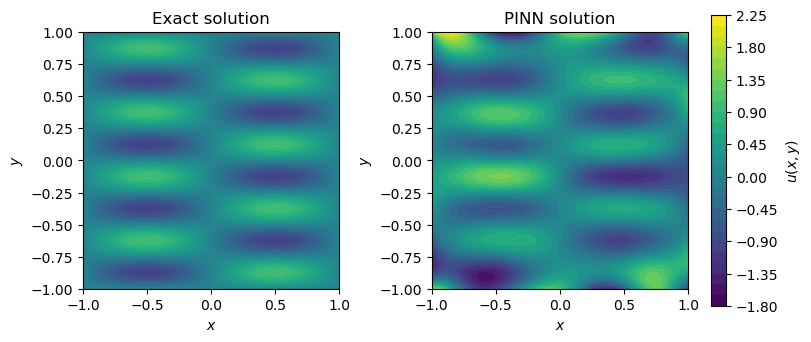

In [22]:
import matplotlib.gridspec as gridspec 


# Predicted solution
U_pred = u_pred.reshape(N, N)
U_true = u_test.reshape(N, N) 
XX = X_test[:, 0:1].reshape(N, N) 
YY = X_test[:, 1:2].reshape(N, N) 
# Use the same color scale for both plots
vmin = min(U_true.min(), U_pred.min())
vmax = max(U_true.max(), U_pred.max())

# Create figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 3.5),
    constrained_layout=True
)

# -----------------------------
# Exact solution
# -----------------------------
contour0 = axes[0].contourf(
    XX, YY, U_true,
    levels=30,
    vmin=vmin,
    vmax=vmax,
    cmap="viridis"
)

axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
axes[0].set_title("Exact solution")
axes[0].set_aspect("equal")

# -----------------------------
# Random feature solution
# -----------------------------
contour1 = axes[1].contourf(
    XX, YY, U_pred,
    levels=30,
    vmin=vmin,
    vmax=vmax,
    cmap="viridis"
)

axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
axes[1].set_title("PINN solution")
axes[1].set_aspect("equal")

# -----------------------------
# Shared colorbar
# -----------------------------
cbar = fig.colorbar(
    contour1,
    ax=axes,
    shrink=0.9,
    pad=0.02
)
cbar.set_label(r"$u(x,y)$")

# -----------------------------
# Save figure
# -----------------------------
""" 
fig.savefig(
    "Helmholtz_solution_ELM.pdf",
    bbox_inches="tight"
)
""" 

plt.show()

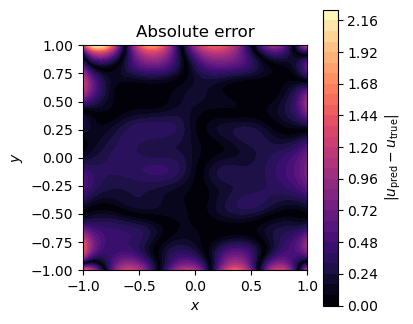

In [23]:
# Absolute error
error = np.abs(U_pred - U_true)

# Create figure
fig, ax = plt.subplots(
    1, 1,
    figsize=(4, 3.5),
    constrained_layout=True
)

# -----------------------------
# Absolute error
# -----------------------------
contour = ax.contourf(
    XX, YY, error,
    levels=30,
    cmap="magma"
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title("Absolute error")
ax.set_aspect("equal")

# -----------------------------
# Colorbar
# -----------------------------
cbar = fig.colorbar(
    contour,
    ax=ax,
    shrink=0.9,
    pad=0.02
)
cbar.set_label(r"$|u_{\mathrm{pred}}-u_{\mathrm{true}}|$")

# -----------------------------
# Save figure
# -----------------------------
"""
fig.savefig(
    "Helmholtz_error_ELM.pdf",
    bbox_inches="tight"
)
"""

plt.show()